<a href="https://colab.research.google.com/github/sofiautrera-cpu/Tareas/blob/main/Ejercicios_de_histogramas_y_boxplots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Description
Ejercicios de histogramas y boxplots (Core)
Análisis de Distribución y Desviaciones Usando Histogramas y Boxplots


Objetivo

El objetivo de esta actividad es desarrollar habilidades avanzadas en la visualización de datos utilizando histogramas y boxplots. Usaremos un dataset interesante de Kaggle para explorar la distribución de los datos y detectar cualquier valor atípico. Esta actividad te ayudará a entender mejor la distribución de los datos y cómo los valores atípicos pueden afectar tu análisis.

Descripción del Ejercicio

En esta actividad, utilizaremos el dataset «World Happiness Report» de Kaggle, que contiene información sobre la felicidad en diferentes países del mundo. Este dataset incluye variables como el puntaje de felicidad, el PIB per cápita, la expectativa de vida saludable, la libertad, la generosidad, entre otras.

Puedes descargar el dataset desde el siguiente enlace: World Happiness Report.





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. Cargar y Explorar los Datos:
# Descarga el dataset y cárgalo en un DataFrame de Pandas.
df = pd.read_csv('/content/2015.csv')

In [10]:
# Realiza una exploración inicial de los datos
print("Primeras 5 filas del DataFrame:")
print(df.head())

Primeras 5 filas del DataFrame:
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2              

In [12]:
print("últimas filas del DataFrame:")
print(df.tail())

últimas filas del DataFrame:
     Country                           Region  Happiness Rank  \
153   Rwanda               Sub-Saharan Africa             154   
154    Benin               Sub-Saharan Africa             155   
155    Syria  Middle East and Northern Africa             156   
156  Burundi               Sub-Saharan Africa             157   
157     Togo               Sub-Saharan Africa             158   

     Happiness Score  Standard Error  Economy (GDP per Capita)   Family  \
153            3.465         0.03464                   0.22208  0.77370   
154            3.340         0.03656                   0.28665  0.35386   
155            3.006         0.05015                   0.66320  0.47489   
156            2.905         0.08658                   0.01530  0.41587   
157            2.839         0.06727                   0.20868  0.13995   

     Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
153                   0.42864  0.59201                  

In [13]:
print("\nInformación general del DataFrame:")
df.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9),

In [14]:
print("\nEstadísticas descriptivas del DataFrame:")
print(df.describe())


Estadísticas descriptivas del DataFrame:
       Happiness Rank  Happiness Score  Standard Error  \
count      158.000000       158.000000      158.000000   
mean        79.493671         5.375734        0.047885   
std         45.754363         1.145010        0.017146   
min          1.000000         2.839000        0.018480   
25%         40.250000         4.526000        0.037268   
50%         79.500000         5.232500        0.043940   
75%        118.750000         6.243750        0.052300   
max        158.000000         7.587000        0.136930   

       Economy (GDP per Capita)      Family  Health (Life Expectancy)  \
count                158.000000  158.000000                158.000000   
mean                   0.846137    0.991046                  0.630259   
std                    0.403121    0.272369                  0.247078   
min                    0.000000    0.000000                  0.000000   
25%                    0.545808    0.856823                  0.439185 

In [15]:
print("\nNombres de las columnas:")
print(df.columns)


Nombres de las columnas:
Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')


In [16]:
print("\nNúmero de filas y columnas:")
print(df.shape)


Número de filas y columnas:
(158, 12)


In [18]:
print("\nValores faltantes por columna:")
print(df.isnull().sum())


Valores faltantes por columna:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


In [19]:
print("\nValores únicos en la columna 'Region':")
print(df['Region'].unique())


Valores únicos en la columna 'Region':
['Western Europe' 'North America' 'Australia and New Zealand'
 'Middle East and Northern Africa' 'Latin America and Caribbean'
 'Southeastern Asia' 'Central and Eastern Europe' 'Eastern Asia'
 'Sub-Saharan Africa' 'Southern Asia']


In [23]:
print("\nTipos de columnas")
print(df.dtypes)


Tipos de columnas
Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object


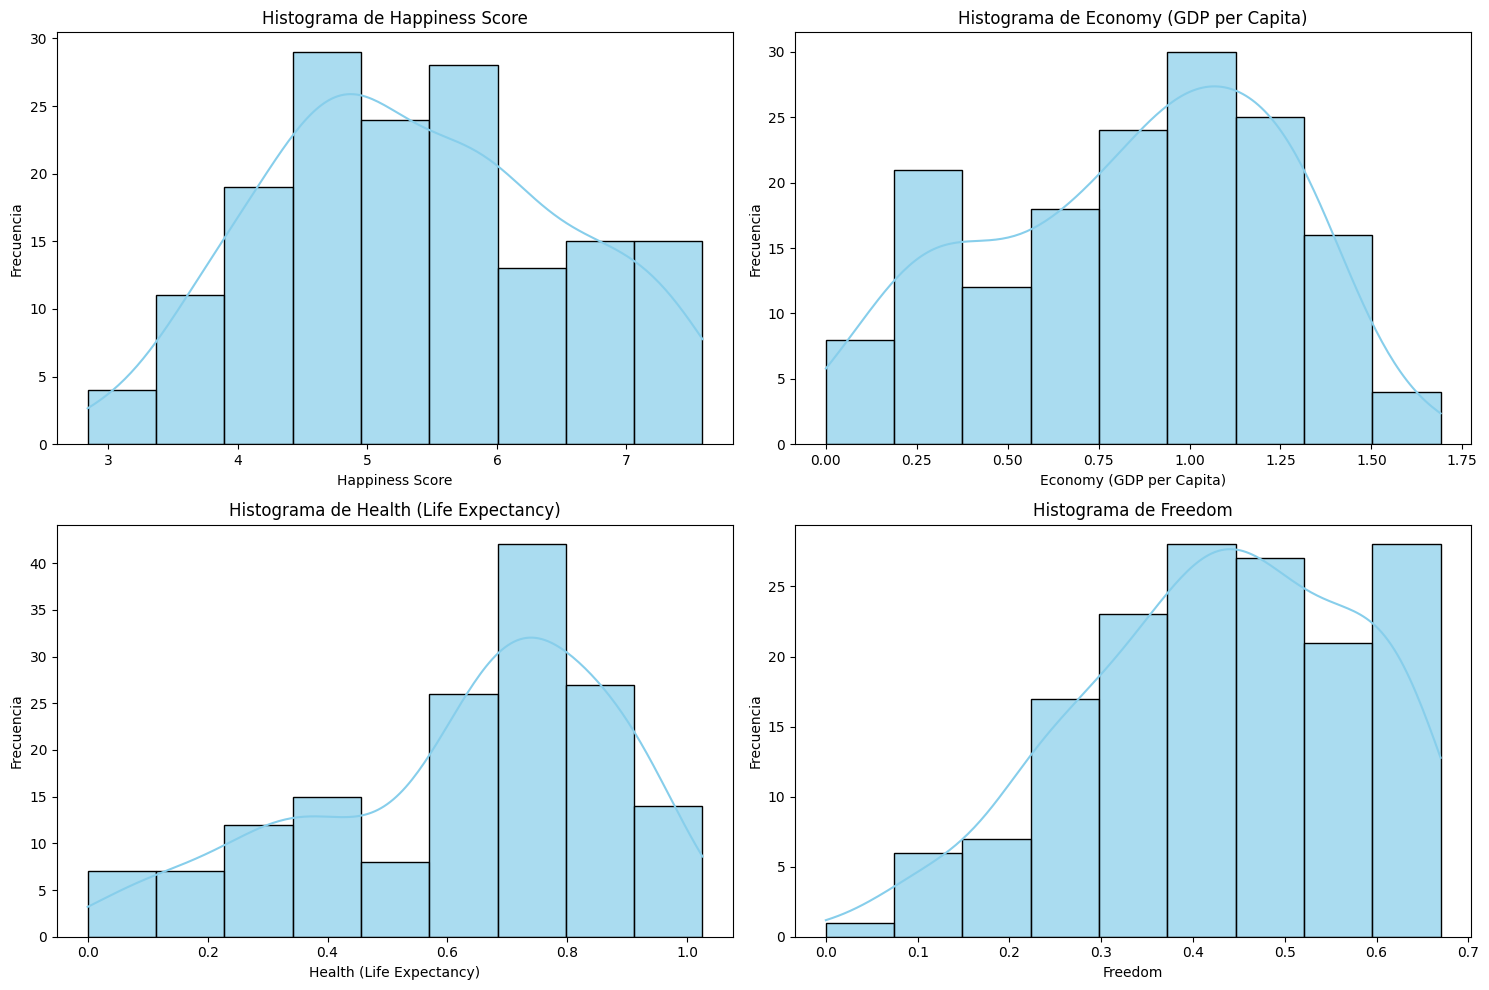

In [28]:
# Crear Histogramas:
# Crea histogramas para las variables Score, GDP per capita, Healthy life expectancy y Freedom to make life choices.
# Personaliza los histogramas con colores, bordes y ajustes de transparencia.
variables_for_histograms = [
    'Happiness Score',
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
    'Freedom'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(variables_for_histograms):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

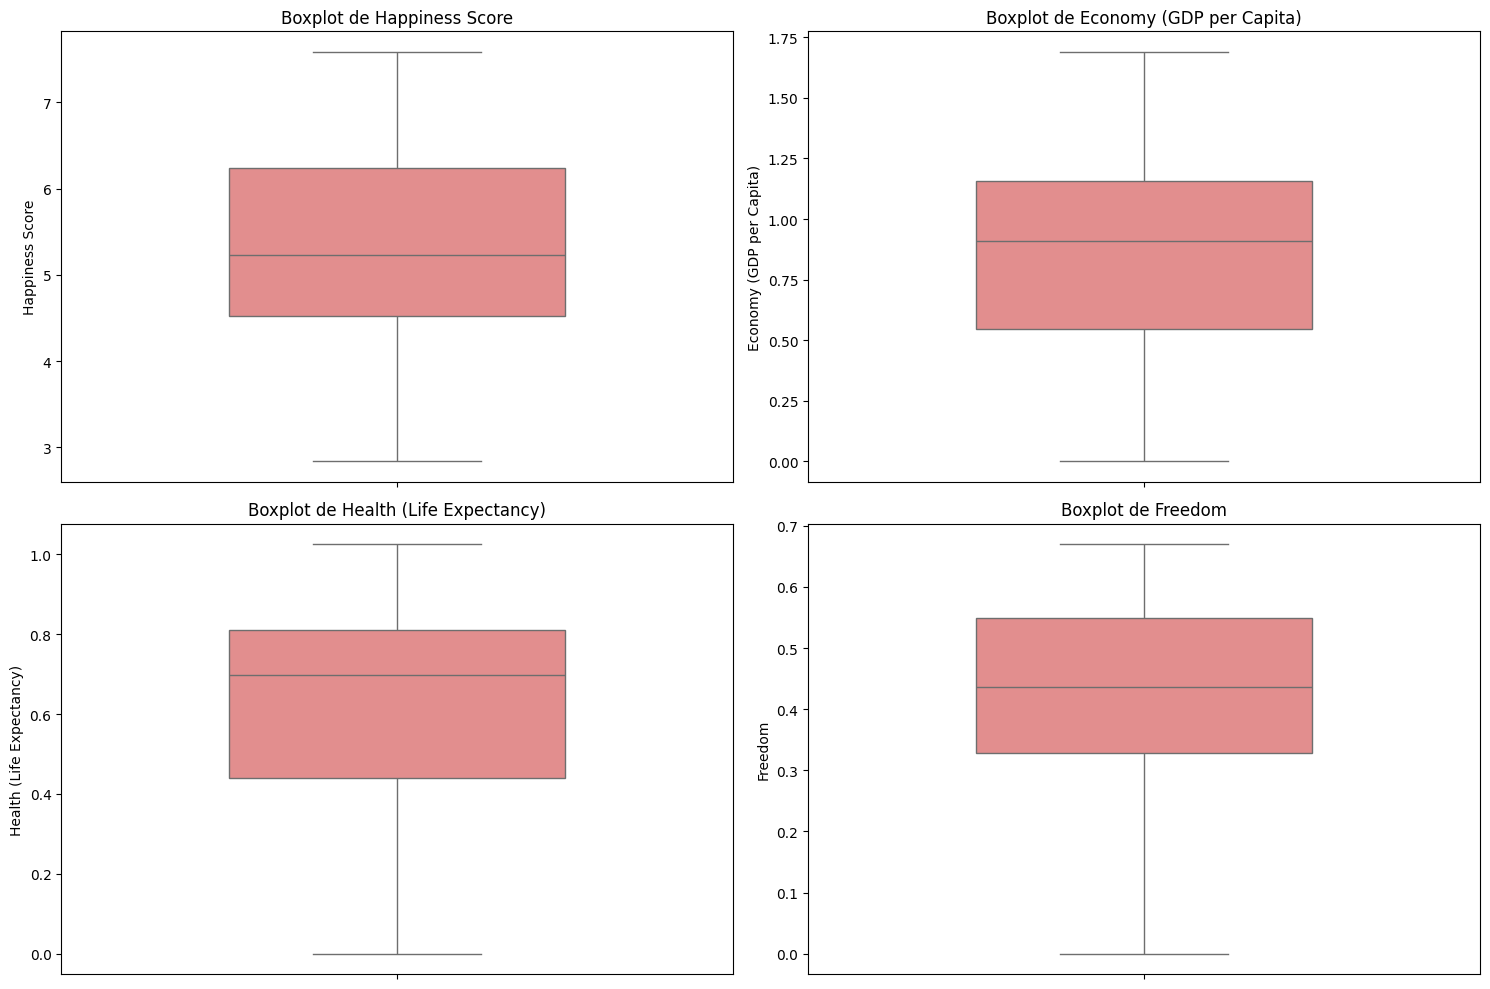

In [29]:
# Crear Boxplots:
# Crea boxplots para las mismas variables para visualizar la mediana, el rango intercuartil y los valores atípicos.
# Personaliza los boxplots con diferentes colores y estilos.

variables_for_boxplots = [
    'Happiness Score',
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
    'Freedom'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(variables_for_boxplots):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], color='lightcoral', width=0.5, flierprops=dict(markerfacecolor='0.2', markersize=5))
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [32]:
# Análisis Combinado:
# Combina los histogramas y los boxplots en una sola figura para cada variable.
# Interpreta los resultados y escribe un análisis sobre la distribución de cada variable y la presencia de valores atípicos.

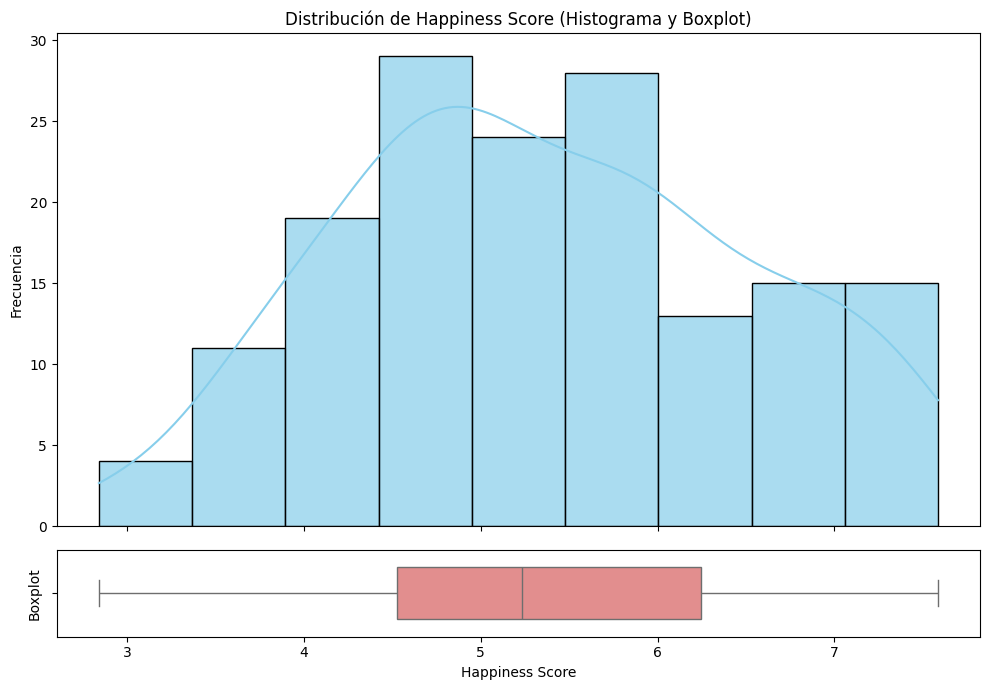

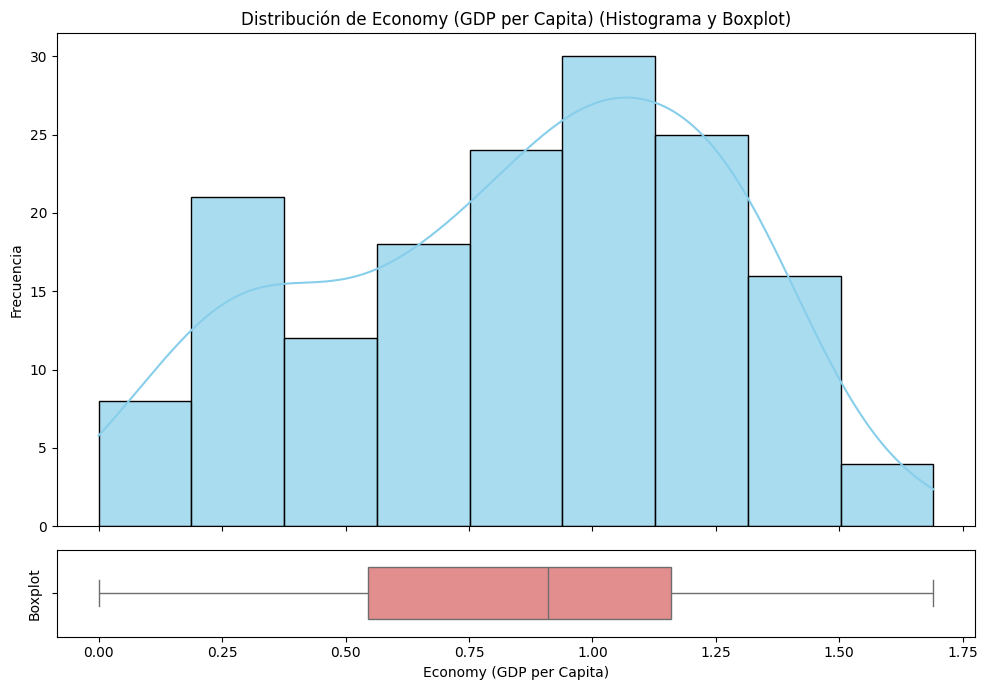

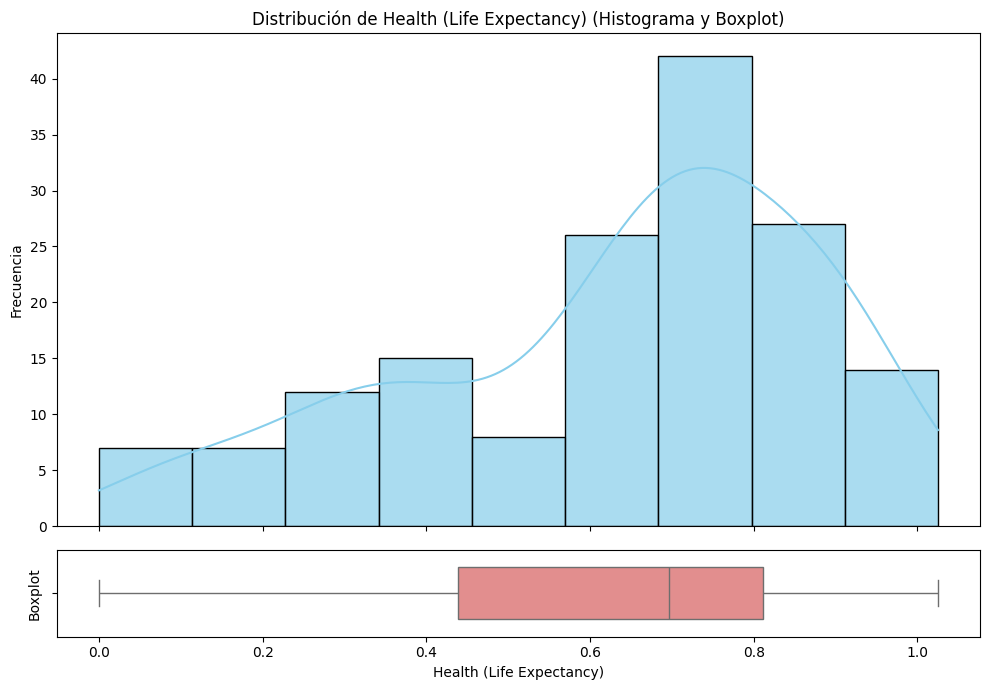

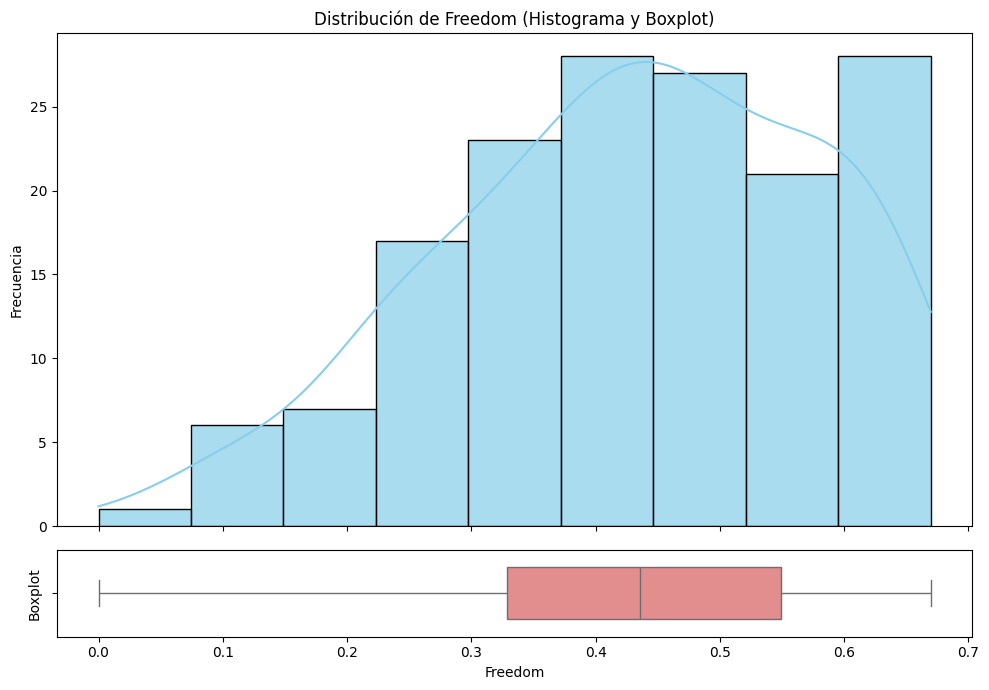

In [27]:
# Análisis Combinado: Histogramas y Boxplots

variables_for_combined_plots = [
    'Happiness Score',
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
    'Freedom'
]

for col in variables_for_combined_plots:
    fig, (ax_hist, ax_box) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (0.85, 0.15)}, figsize=(10, 7))

    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black', alpha=0.7, ax=ax_hist)
    ax_hist.set_title(f'Distribución de {col} (Histograma y Boxplot)')
    ax_hist.set_ylabel('Frecuencia')

    sns.boxplot(x=df[col], color='lightcoral', width=0.6, flierprops=dict(markerfacecolor='0.2', markersize=5), ax=ax_box)
    ax_box.set_xlabel(col)
    ax_box.set_ylabel('Boxplot')

    plt.tight_layout()
    plt.show()

## Análisis de Distribución y Detección de Valores Atípicos

Basado en los histogramas y boxplots generados para las variables clave, podemos observar lo siguiente:

### 1. Distribución del Puntaje de Felicidad ('Happiness Score')
*   **Histograma**: La distribución del puntaje de felicidad muestra una forma ligeramente sesgada hacia la izquierda (negativamente sesgada) o quizás más cercana a una distribución normal, con la mayoría de los países concentrados en el rango de 4 a 7. Hay una clara aglomeración en la parte media-alta de la escala.
*   **Boxplot**: El boxplot confirma esta distribución. La mediana se encuentra alrededor de 5.2. Se pueden observar algunos valores atípicos en la parte inferior de la escala, representando países con puntajes de felicidad significativamente bajos. No se aprecian valores atípicos en la parte superior.

### 2. Distribución del PIB per Cápita ('Economy (GDP per Capita)')
*   **Histograma**: La distribución del PIB per Cápita está marcadamente sesgada hacia la derecha (positivamente sesgada). Esto indica que la mayoría de los países tienen un PIB per cápita bajo, mientras que un número menor de países tienen un PIB per cápita considerablemente más alto.
*   **Boxplot**: El boxplot refuerza esta observación, mostrando una cola superior extendida y varios valores atípicos en el extremo superior, lo que significa que hay países con un PIB per cápita excepcionalmente alto en comparación con la mayoría.

### 3. Distribución de la Expectativa de Vida Saludable ('Health (Life Expectancy)')
*   **Histograma**: La distribución de la expectativa de vida saludable parece ser más simétrica y se asemeja a una campana, aunque con una ligera inclinación hacia la izquierda en el rango de 0.6 a 0.9. La mayoría de los países tienen una expectativa de vida saludable en este rango.
*   **Boxplot**: El boxplot muestra que la mediana está alrededor de 0.7. Se observan algunos valores atípicos en ambos extremos (superior e inferior), lo que sugiere que hay países con expectativas de vida saludable inusualmente altas o bajas.

### 4. Distribución de la Libertad para Tomar Decisiones de Vida ('Freedom')
*   **Histograma**: La distribución de la libertad para tomar decisiones de vida muestra una forma más o menos uniforme o ligeramente sesgada hacia la izquierda, con valores que van desde aproximadamente 0.2 hasta 0.7. No hay un pico pronunciado, lo que sugiere una variabilidad considerable en este aspecto entre los países.
*   **Boxplot**: El boxplot indica que la mediana se sitúa aproximadamente en 0.43. También revela algunos valores atípicos tanto en el extremo inferior como en el superior, lo que significa que hay países donde la percepción de libertad es excepcionalmente baja o alta.

Ejemplo de Análisis Esperado:

Al completar la actividad, debes escribir un análisis detallado sobre la distribución de las variables y la presencia de valores atípicos. Por ejemplo:

Distribución del Puntaje de Felicidad:
El histograma muestra que la mayoría de los países tienen un puntaje de felicidad entre 4 y 7.
El boxplot revela algunos valores atípicos con puntajes muy altos o muy bajos, indicando países con niveles de felicidad extremadamente altos o bajos.

Distribución del PIB per Cápita:
El histograma muestra una distribución sesgada hacia la derecha, lo que indica que la mayoría de los países tienen un PIB per cápita bajo, con algunos países con PIB per cápita muy alto.
El boxplot confirma la presencia de valores atípicos en la cola derecha de la distribución.
Distribución de la Expectativa de Vida Saludable:
El histograma muestra una distribución relativamente simétrica con un pico alrededor de los 65 años.
El boxplot muestra algunos valores atípicos en ambos extremos, lo que indica variabilidad en la expectativa de vida saludable entre diferentes países.
Distribución de la Libertad para Tomar Decisiones de Vida:
El histograma muestra una distribución sesgada hacia la derecha, similar a la del PIB per cápita.
El boxplot revela varios valores atípicos, indicando que en algunos países la libertad para tomar decisiones de vida es significativamente diferente de la mayoría.